# Tree Based Models

Tree based models such as decision trees are a class of machine learning models that are used for both classification and regression. The model is essentially a series of binary questions, where the trained models resemble a tree, with branches and nodes that contains all the combination of responses. Tree based models are explicability models and are easy to understand and explain.

## Ensemble models

Ensemble models are machine learning models that use more than one predictor to arrive at a prediction. A group of predictors form an ensemble. In general, ensemble models perform better than using a single predictor (model) with improved efficiency and accuracy.

Ensemble learning can be classified as

- Bagging ensemble learning also referred as parallel ensemble
- Boosting ensemble learning also referred as sequntial ensemble

Decision trees have been used predominantly to construct bagging and boosting based models in machine learning.

### Bagging

A tree based model that aggregates the predictions of multiple trees is a Random Forest model. For it to be effective, the model needs a diverse collection of trees. Random Forest uses bootstrapping and aggregate results to perform operation and is also referred to as ***bagging ensemble model***.

### Boosting

Boosting is a process that uses a set of Machine Learning algorithms to combine weak learner to form strong learners in order to increase the accuracy of the model. The basic principle behind the working of boosting algorithms is to generate multiple weak learners and combine their predictions to form one strong rule.

- Step 1: The base algorithm reads the data and assigns equal weight to each sample observation


- Step 2: False predictions are assigned to the next base learner with a higher weightage on these incorrect predictions (increase the weightage on the misclassified samples)


- Step 3: Repeat step2 until the algo can correctly classify the output

![Figure1 ](https://www.edureka.co/blog/wp-content/uploads/2019/06/How-Does-Boosting-Algorithm-Work-Boosting-Machine-Learning-Edureka-min-528x254.png)

# Gradient Boosting

Gradient boosting trees are another ensemble model where tree models are arranged in a sequence. The model is built sequentially as each additional tree aims to correct the previously built model's predictions. A model with $M$ trees is equal to

$$ f_M(x_j) = \sum_{m=1}^M \gamma_m h_m (x_j) $$

, where $h_m$ is a **weak learner** decision tree.

**Additive Training**:  It is quite difficult to learn all the trees at once and we use an additive strategy which is fixing what it learned till last time step (tree) and add one new tree at a time. Then, we can write the prediction at step $\tilde{y}_i^{(t)}$. Then, we have,

$ f_0(x_j) = h_0 (x_j) $

$ f_1(x_j) = f_0(x_j) + \gamma_1 h_1 (x_j) $

$ f_2(x_j) = f_1(x_j) + \gamma_2 h_2 (x_j) $

$\cdots$

$ f_M(x_j) = f_{M-1}(x_j) + \gamma_M h_M (x_j) $

, where $m$ is the number of trees, $f$ is a function in the functional space $F$.

In random forest, diversification is achieved through many trees that will possibly improve the overall quality of the model. Gradient boosing algorithm combine multiple weak learners to form a strong learner.

The model is usually initialized with $h_0$ being equal to the mean of the training labels for regression or the majority class for classification. $\gamma_m$ is a factor that scales the contribution of a tree to the overall model. The model is then trained iteratively for $h_m$ by selecting $\gamma_m$ that minimizes the loss function $L(y,f_m)$. This is repeated until the model includes all $M$ trees.

The two most popular gradiant boosting algorithms are

- Adaboost: Improves the learning process by focusing on the instances that yield the largest errors.
- XGBboost: Flexible algorithm in which each new tree is only focused on the minimization of the training sample loss.

# XGBoost

Tree boosting is highly effective and widely used machine learning method. XGBoost stands for “Extreme Gradient Boosting”, where the term “Gradient Boosting” originates from the paper Greedy Function Approximation: A Gradient Boosting Machine, by Friedman.

XGBoost, which is used widely by data scientists to achieve state-of-the-art results on many machine learning challenges. XGBoost initially started as a research project by Tianqi Chen as part of the Distributed (Deep) Machine Learning Community (DMLC) group. Initially, it began as a terminal application which could be configured using a libsvm configuration file.

XGBoost was designed to be used with large, complicated datasets and is one of the most popular machine learning algorithm to deal with structured data. It is an advance version of gradient boosting method that is designed to focus on computational speed and model efficiency. XGBoost is preferred over other tree based model as it supports

- Parallelization
- Distributed computing methods
- Out-of-core computing

- Cache optimization

The algorithm is highly customizable and accurate in its predictions as it seeks to minimise the objective function,

$$Obj^{(t)} = \underbrace{\sum_{i=1}^n l(y_i, \tilde{y}_i^{(t)})}_{\text{trainning loss}} + \underbrace{\sum_{t=1}^t \Omega(f_i)}_{\text{regularisation term}}  $$

$$Obj^{(t)} = \sum_{i=1}^n l(y_i, \tilde{y}_i^{(t-1)} + f_t(x_i)) + \sum_{t=1}^t \Omega(f_i)  $$

The first term (over all instances) measures the distance between the true label and the output from the model while the second term (over all trees) penalises models that are too complex. Optimising loss tend to create more complex models while optimizing regularisation tends to generalise simplier models.

In XGBoost, we define the complexity as,

$$ \Omega(f) = \gamma T +\frac{1}{2}\lambda w_j^2 $$

, where

- $T$ is the number of terminal nodes, or leaves in a tree,
- $\gamma$ and $\lambda$ are regularisation terms which is a user definable penalty for pruning

> - $\gamma$: minimum loss reduction required to make a further partition on a leaf node of the tree. Large gamma will lead to more conservative algorithm. 
> - $\lambda$: L2 regularization term on weights. Increasing this value will make model more conservative. Normalised to number of training examples.

- $w_j^2$ is the score of each leaf.

While metrics for regression is straight forward, it can be complex for classification (logistic loss) where we use Taylor expansion of the loss function up to the second order. After removing all the constants, the specific objective (function) at step $t$ becomes,

$$ \sum_{i=1}^n [ g_i f_t (x_i) +\frac{1}{2} h_i f_t^2 (x_i) ] + \Omega(f_t) $$

, where the $g_i$ and $h_i$ are defined as,

$$g_i = \partial_{\tilde{y}_i^{(t-1)}} l(y_i, \tilde{y}_i^{(t-1)})$$

$$h_i = \partial^2_{\tilde{y}_i^{(t-1)}} l(y_i, \tilde{y}_i^{(t-1)})$$

Refer [here](https://xgboost.readthedocs.io/en/latest/tutorials/model.html) for further details.

Manipulating the above formulation for classification, the leaf output is given as

$$\frac{\sum R_i}{\sum[P_i \times (1-P_i)]+\lambda}$$

,where, $R$ is the residual; $P_i$ is the previous probability; $\lambda$ is the regularization parameter.

# Implementation

We will use XGBClassifier from XGBoost library to predict future prices of the security by creating a custom list of features from the raw price series.

## Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20,10)
plt.style.use('fivethirtyeight')

# XGBoost Classifier
from xgboost import XGBClassifier, plot_importance, Booster, plot_tree, to_graphviz, DMatrix

# Preprocessing & Cross validation
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Retrieve Data

We will retrieve the adjusted closed price of SPY from locally stored data.

In [2]:
# Load file
df = pd.read_csv('spy.csv', index_col=0, parse_dates=True)[['Adj Close']]

# Calculate returns
df['Returns'] = np.log(df).diff()
df['Ret_1M'] = df['Returns'].rolling(20).sum()

# Output first five values
df.head()

,Adj Close,Returns,Ret_1M
Date,,,
1999-12-31,100.376900,NaN,NaN
2000-01-03,99.394493,-0.009835,NaN
2000-01-04,95.507530,-0.039892,NaN
2000-01-05,95.678391,0.001787,NaN
2000-01-06,94.140717,-0.016202,NaN


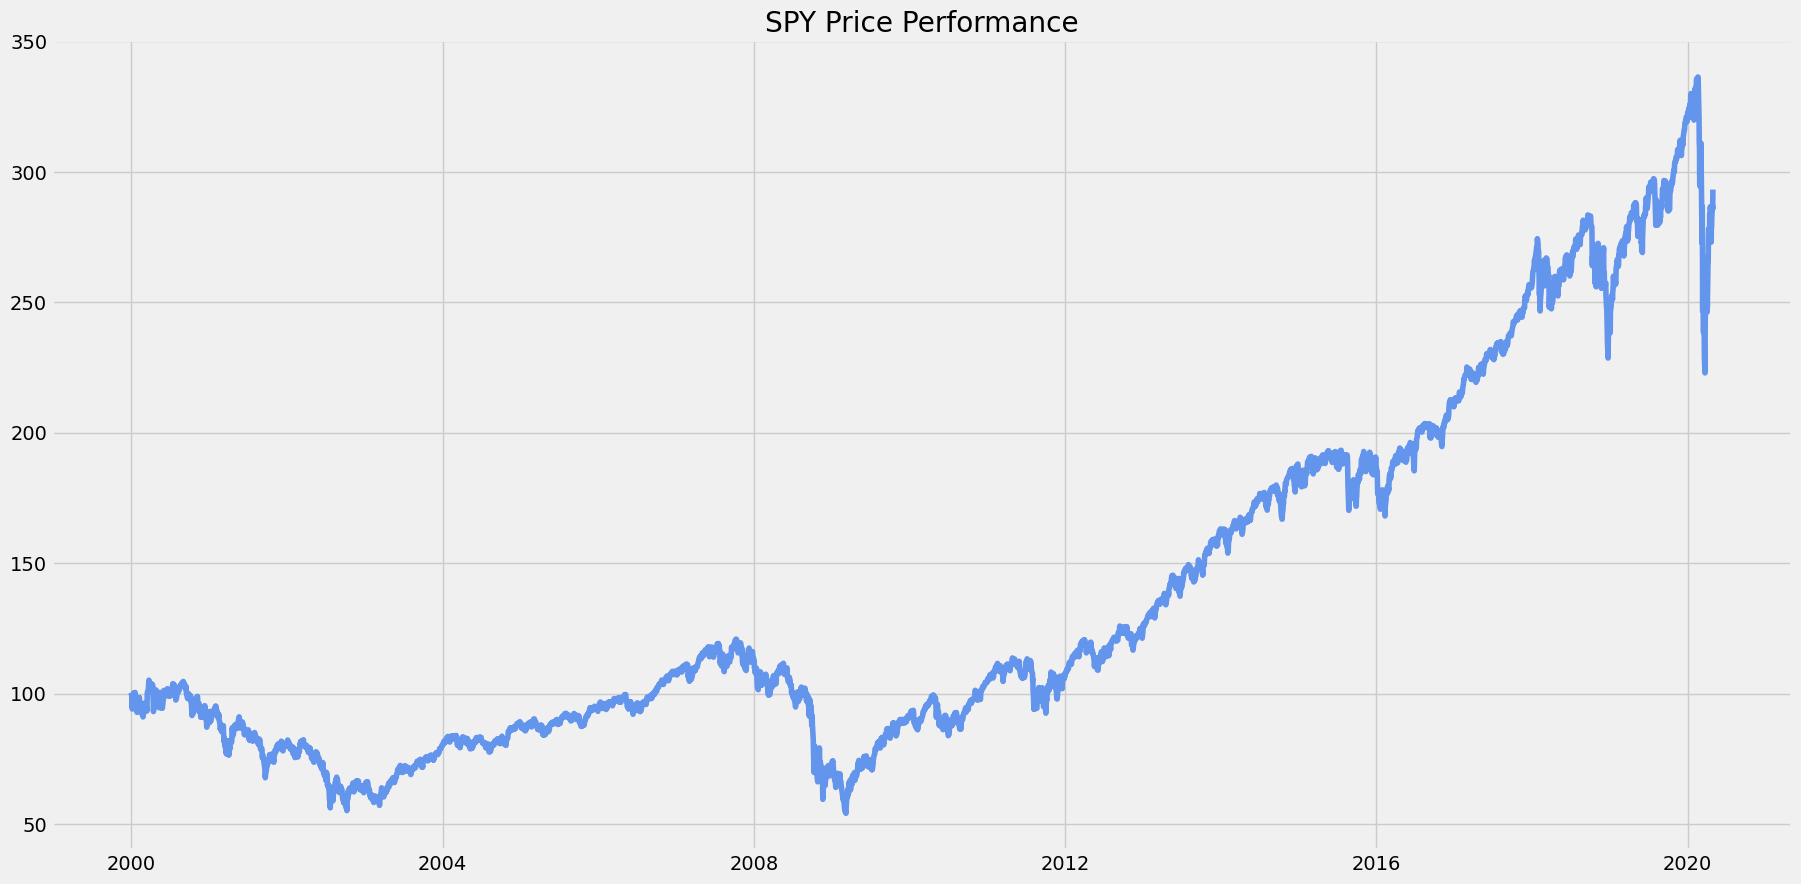

In [3]:
# Visualize raw price series
plt.title('SPY Price Performance')
plt.plot(df['Adj Close'], color='cornflowerblue')

## Feature Specification

Features or Predictors are also known as an independent variable which are used to determine the value of the target variable. We will use raw price to derive list of custom features.

In [4]:
# Create features (predictors) list
features_list = []
for r in range(10, 65, 5):
    df['Ret_'+str(r)] = df.Returns.rolling(r).sum()
    df['Std_'+str(r)] = df.Returns.rolling(r).std()
    features_list.append('Ret_'+str(r))
    features_list.append('Std_'+str(r))

# Drop NaN values
df.dropna(inplace=True)

## Define Label

Label or the target variable is also known as the dependent variable. Here, the target variable is whether one month SPY return is above 
0.154% or not. If the yesterday's monthly return is above this threshold, we will initiate a long position. We assign a value of one for the bu 
signal and zero otherwise to the target variable. The target can be described s :

$$ y_t = \begin{cases} 
1, & \text{if}\ \ p_{t+1}>0.995 \times p_t \\
0, & \text{Otherwise} 
\end{cases} $$


where, $p_t$ is the current closing price of SPY and $p_{t+1}$ is the 1-day forward closing price of SPY.

In [5]:
# Define Target
df['Target'] = np.where(df['Ret_1M'].shift(1)>0.00154,1,0)

# Check output
df

,Adj Close,Returns,Ret_1M,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,...,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60,Target
Date,,,,,,,,,,,,,,,,,,,,,
2000-03-28,103.501099,-0.005776,0.097063,0.102992,0.016808,0.099909,0.017161,0.097063,0.016531,0.115189,...,0.015079,0.076137,0.015692,0.030012,0.015742,0.038339,0.015368,0.030650,0.017420,0
2000-03-29,103.608170,0.001034,0.090847,0.080964,0.016388,0.102198,0.017096,0.090847,0.016542,0.104483,...,0.015027,0.065879,0.015623,0.038945,0.015694,0.035949,0.015363,0.041519,0.017367,1
2000-03-30,101.873848,-0.016881,0.073289,0.018427,0.011734,0.056512,0.016967,0.073289,0.017210,0.107945,...,0.015315,0.056956,0.015801,0.013952,0.015853,0.031106,0.015451,0.064530,0.016697,1
2000-03-31,103.030037,0.011285,0.066024,0.023125,0.012035,0.073135,0.016873,0.066024,0.016954,0.122857,...,0.015243,0.072244,0.015850,0.040662,0.015763,0.052389,0.015448,0.074028,0.016749,1
2000-04-03,103.629585,0.005802,0.081618,0.034044,0.011779,0.089925,0.016292,0.081618,0.016677,0.107899,...,0.015233,0.109737,0.015023,0.048626,0.015772,0.044739,0.015368,0.096032,0.016601,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-23,279.079987,-0.000072,0.122961,0.018261,0.021258,0.125557,0.025494,0.122961,0.029821,0.156723,...,0.046138,-0.186690,0.043884,-0.177545,0.041639,-0.158879,0.039758,-0.152262,0.038192,1
2020-04-24,282.970001,0.013842,0.080054,0.017001,0.021175,0.116587,0.025235,0.080054,0.027437,0.168442,...,0.045663,-0.168731,0.043966,-0.170125,0.041688,-0.156518,0.039775,-0.137593,0.038250,1
2020-04-27,287.049988,0.014315,0.124608,0.040488,0.021137,0.145462,0.024500,0.124608,0.026296,0.226808,...,0.045725,-0.144063,0.044036,-0.154741,0.041763,-0.145562,0.039834,-0.126518,0.038304,1


Text(0.5, 1.0, 'Feature Correlation')

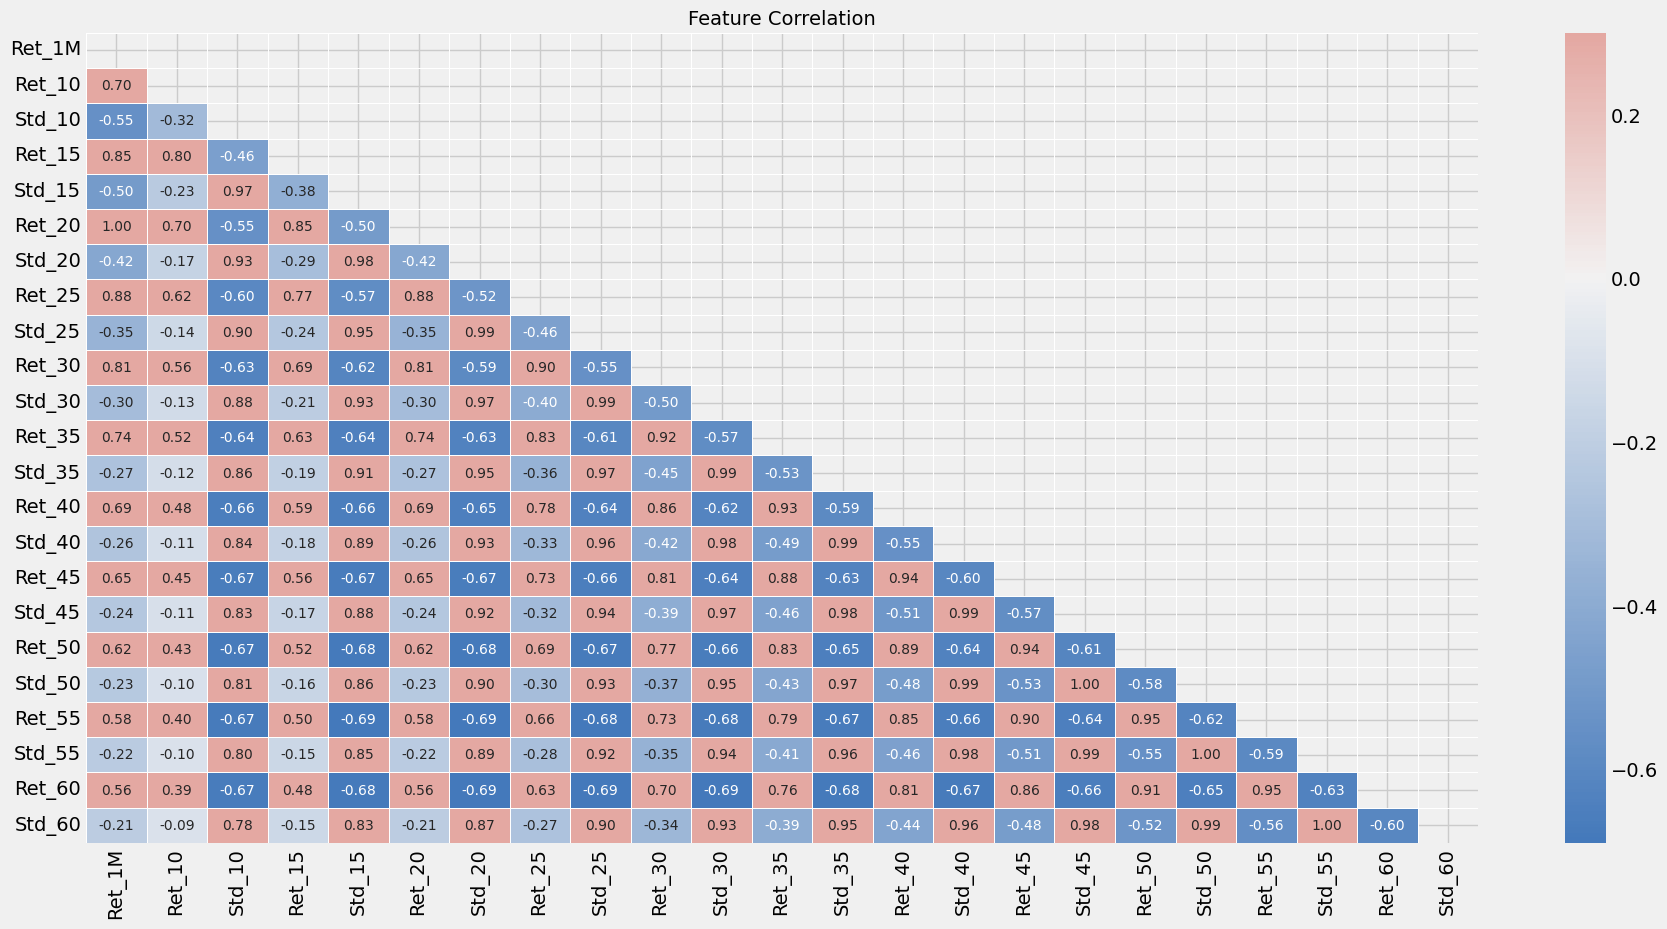

In [6]:
# Derive features correlation
import seaborn as sns
corrmat = df.drop(['Adj Close', 'Returns', 'Target'],axis=1).corr()

# Visualize feature correlation
fig, ax = plt.subplots()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corrmat, dtype=bool))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(250, 15, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corrmat, annot=True, annot_kws={"size": 10},
            fmt="0.2f", mask=mask, cmap=cmap, vmax=.3, center=0,
            square=False, linewidths=.5, cbar_kws={"shrink": 1})
ax.set_title('Feature Correlation', fontsize=14, color='black')

In [7]:
# Convert to NumPy
X = df.drop(['Adj Close', 'Returns', 'Ret_1M', 'Target'],axis=1)
X.values

array([[ 0.10299217,  0.01680829,  0.09990879, ...,  0.01536765,
         0.03065013,  0.01742033],
       [ 0.08096385,  0.01638798,  0.10219782, ...,  0.01536317,
         0.04151947,  0.01736735],
       [ 0.01842677,  0.01173377,  0.05651238, ...,  0.01545088,
         0.06453017,  0.01669711],
       ...,
       [ 0.04048814,  0.02113725,  0.14546178, ...,  0.03983401,
        -0.12651806,  0.03830417],
       [ 0.00681279,  0.01931243,  0.07584602, ...,  0.03983321,
        -0.11280233,  0.03824664],
       [ 0.05413158,  0.01907551,  0.10066876, ...,  0.03999635,
        -0.09436169,  0.03839629]])

In [8]:
X.shape

(5054, 22)

In [9]:
# Define label or target 
y = df['Target']
y

Date
2000-03-28    0
2000-03-29    1
2000-03-30    1
2000-03-31    1
2000-04-03    1
             ..
2020-04-23    1
2020-04-24    1
2020-04-27    1
2020-04-28    1
2020-04-29    1
Name: Target, Length: 5054, dtype: int32

In [10]:
y.shape

(5054,)

## Split Data

In [11]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 4043, 1011


## Fit Model
We will now create and train the XGBoost (Regessor). All the feature and label should have a similar scale and the scaling can be accomplished by using the `StandardScaler` transformer.

In [12]:
# Scale and fit the classifier model
xgbcls = XGBClassifier()
xgbcls.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [13]:
import xgboost
import sklearn
print("XGBoost version:", xgboost.__version__)
print("Scikit-learn version:", sklearn.__version__)

XGBoost version: 2.1.4
Scikit-learn version: 1.6.1


## Predict Model

In [14]:
# Predicting the test dataset
y_pred = xgbcls.predict(X_test)

In [15]:
# Output prediction scoare
print(f'Train Accuracy: {xgbcls.score(X_train,y_train):0.4}')
print(f'Test Accuracy: {xgbcls.score(X_test,y_test):0.4}')

Train Accuracy: 1.0
Test Accuracy: 0.9179


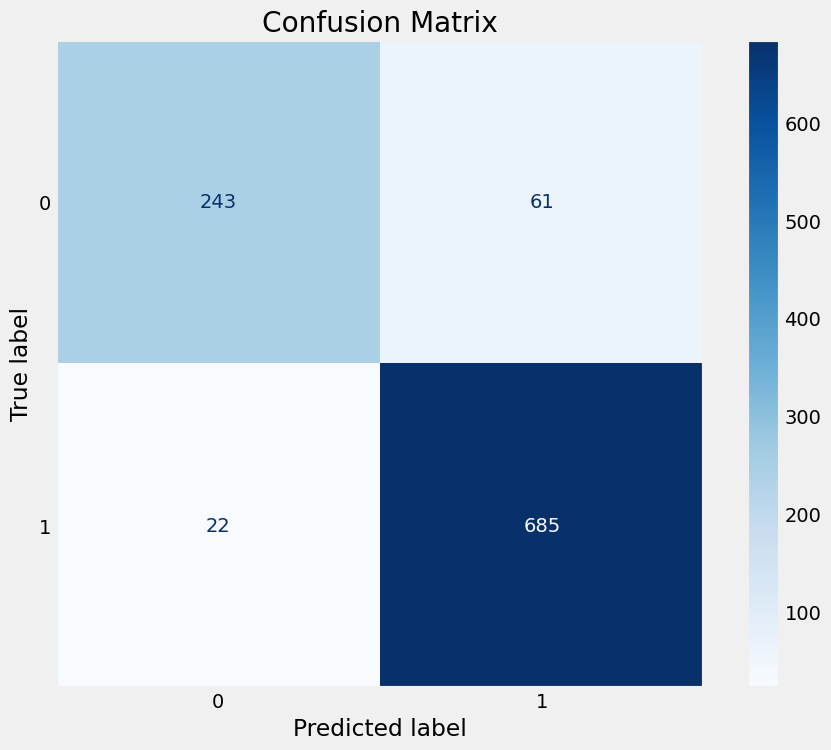

In [17]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# 假设 xgbcls, X_test, y_test 已定义
# 先计算混淆矩阵
y_pred = xgbcls.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues', values_format='.4g')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

In [18]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85       304
           1       0.92      0.97      0.94       707

    accuracy                           0.92      1011
   macro avg       0.92      0.88      0.90      1011
weighted avg       0.92      0.92      0.92      1011



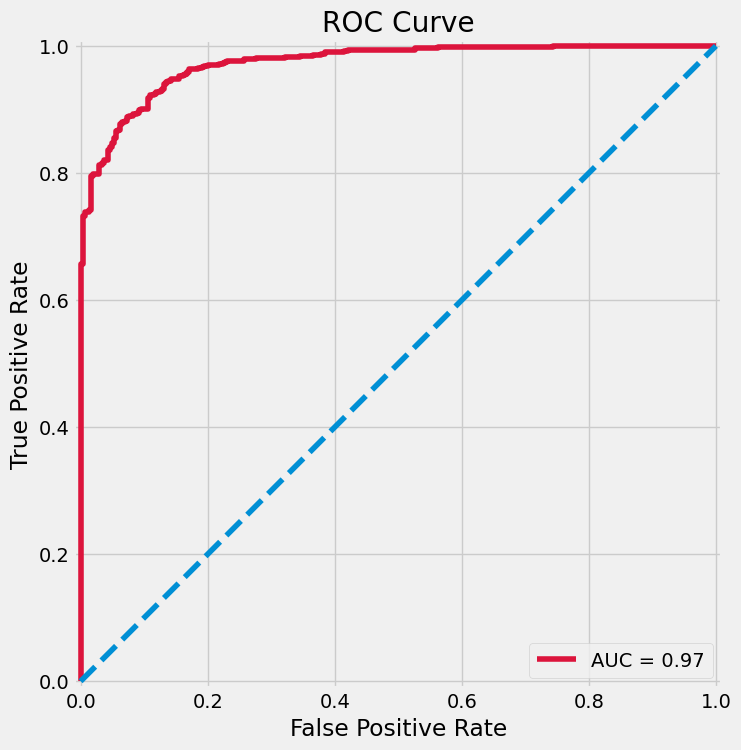

In [20]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# 假设 xgbcls, X_test, y_test 已定义
# 计算 ROC 曲线所需的数据
y_pred_proba = xgbcls.predict_proba(X_test)[:, 1]  # 获取正类的概率
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
fig, ax = plt.subplots(figsize=(10, 8))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax, color='crimson')
ax.plot([0, 1], [0, 1], linestyle='--')  # 绘制对角线
ax.set_title('ROC Curve')
plt.show()

# Hyper-parameter Tuning
Hyper-parameters are parameters that are not directly learnt within estimators. They are passed as arguments to the constructor of the estimator classes (Classifier in this case). It is possible and recommended to search the hyper-parameter space for the best cross validation score. Any parameter provided when constructing an estimator may be optimized in this manner.

We will tune the hyperparameters to select the best score by TimeSeriesSplit cross-validation. This is a variation of KFold. In the kth split, it returns first k folds as train set and the (k+1)th fold as test set. Unlike standard cross-validation methods, successive training sets are supersets of those that come before them.

## XGBoost's hyper-parameter

XGBoost has plethora of tuning parameters includeing the regulatization parameters and some of the most common hyperparameters are:

- `learning rate`: step size shrinkage used in update to prevents overfitting. Range is [0,1].
- `max_depth`: maximum depth of a tree.
- `colsample_bytree`: percentage of features used per tree. High value can lead to overfitting.
- `min_child_weight`: minimum sum of instance weight needed in a child.
- `gamma`: minimum loss reduction required to make a further partition on a leaf node of the tree. Large gamma will lead to more conservative algorithm.
- `lambda`: L2 regularization term on weights. Increasing this value will make model more conservative. Normalised to number of training examples. [parameter for linear booster].

Refer [here](https://xgboost.readthedocs.io/en/latest/parameter.html#general-parameters) for complete list of tuning parameters.

## Randomised Search

The RandomizedSearchCV implements a “fit” and a “score” method and perform randomized search on hyper parameters. The parameters of the estimator used to apply these methods are optimized by cross-validated search over parameter settings. In contrast to GridSearchCV, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions.

In [21]:
# Timeseries CV 3-split
tscv = TimeSeriesSplit(n_splits=3)
for train, test in tscv.split(X):
    print(train, test)

[   0    1    2 ... 1262 1263 1264] [1265 1266 1267 ... 2525 2526 2527]
[   0    1    2 ... 2525 2526 2527] [2528 2529 2530 ... 3788 3789 3790]
[   0    1    2 ... 3788 3789 3790] [3791 3792 3793 ... 5051 5052 5053]


In [22]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

In [23]:
# Get params list
xgbcls.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [24]:
# Hyper parameter optimization
param_grid = {'learning_rate': [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
              'max_depth': [3, 4, 5, 6, 8, 10, 12, 15],
              'min_child_weight': [1, 3, 5, 7],
              'gamma': [0.0, 0.1, 0.2 , 0.3, 0.4],
              'colsample_bytree': [0.3, 0.4, 0.5 , 0.7]}

In [25]:
random_search = RandomizedSearchCV(xgbcls, param_grid, n_iter=100, scoring='f1', n_jobs=-1, cv=tscv, random_state=42, verbose=1)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=N...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.3, 0.4, 0.5,
                                                             0.7],
                                        'gamma': [0.0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.05, 0.1, 0.15, 0.2,
                                                          0.25, 0.3],
                                        'max_depth': [3, 4, 5, 6, 8, 10, 12,
                                                      15],
                                        'min_child_weight': [1, 3, 5, 7]},
                   random_state=42, scoring='f1', verbose=1)

In [26]:
random_search.best_params_

{'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0.4,
 'colsample_bytree': 0.5}

In [27]:
random_search.best_score_

0.9235723244374323

## Verify Model

Let's now train and predict the model with the best search parameter## Refit Model.

In [29]:
# 假设 random_search.best_params_ 已定义
best_params = random_search.best_params_

# 将 eval_metric 添加到参数中
cls = XGBClassifier(**best_params, eval_metric='logloss')

# 训练模型
cls.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=True)

[0]	validation_0-logloss:0.61700	validation_1-logloss:0.57990
[1]	validation_0-logloss:0.56034	validation_1-logloss:0.52697
[2]	validation_0-logloss:0.52123	validation_1-logloss:0.48999
[3]	validation_0-logloss:0.49294	validation_1-logloss:0.46389
[4]	validation_0-logloss:0.45595	validation_1-logloss:0.42883
[5]	validation_0-logloss:0.42475	validation_1-logloss:0.39984
[6]	validation_0-logloss:0.39807	validation_1-logloss:0.37411
[7]	validation_0-logloss:0.37501	validation_1-logloss:0.35119
[8]	validation_0-logloss:0.35507	validation_1-logloss:0.33193
[9]	validation_0-logloss:0.34540	validation_1-logloss:0.32302
[10]	validation_0-logloss:0.32904	validation_1-logloss:0.30664
[11]	validation_0-logloss:0.31467	validation_1-logloss:0.29222
[12]	validation_0-logloss:0.30230	validation_1-logloss:0.27992
[13]	validation_0-logloss:0.29337	validation_1-logloss:0.27103
[14]	validation_0-logloss:0.28659	validation_1-logloss:0.26491
[15]	validation_0-logloss:0.27715	validation_1-logloss:0.25590
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.4, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [30]:
# Return the evaluation results
evals_result = cls.evals_result()
evals_result

{'validation_0': OrderedDict([('logloss',
               [0.6169962304566657,
                0.5603393161028528,
                0.5212317974576849,
                0.4929427763420905,
                0.4559534780981515,
                0.4247544715745361,
                0.3980742776612082,
                0.37500738146323953,
                0.35506996518310097,
                0.3454033422854877,
                0.32903636656213214,
                0.31466513101104576,
                0.30230229336150116,
                0.2933712022864167,
                0.28659280748715826,
                0.277154110399709,
                0.26869706554656686,
                0.26114915971255614,
                0.25450727948930457,
                0.24846056568284983,
                0.24307071586742338,
                0.2394247360687842,
                0.23474683928539072,
                0.23069225928916395,
                0.22712815746355405,
                0.22521116284433787,
        

Feature Importance refers to techniques that calculate a score for all the input features for a given model where the scores represent the “importance” of each feature. It is calculated as the decrease in node impurity weighted by the probability of reaching that node. The node probability can be calculated by the number of samples that reach the node, divided by the total number of samples. The higher the value the more important the feature.

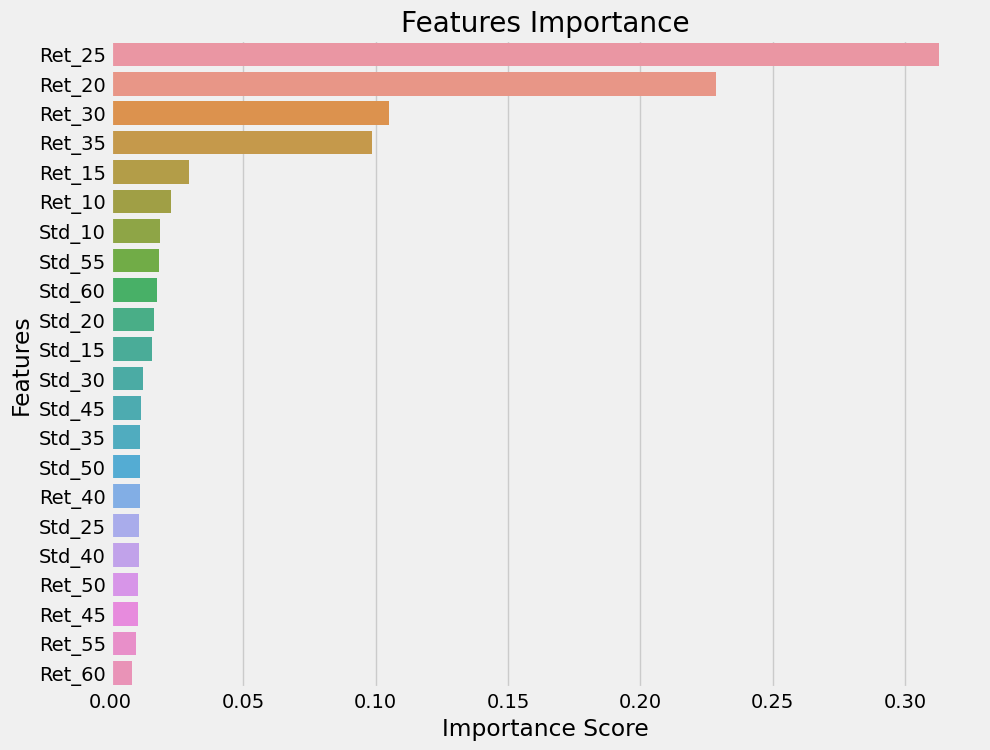

In [31]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10,8))
feature_imp = pd.DataFrame({'Importance Score': cls.feature_importances_,'Features': X.columns}).sort_values(by='Importance Score', ascending=False)

sns.barplot(x=feature_imp['Importance Score'], y=feature_imp['Features'])
ax.set_title('Features Importance');

Importance type can be either of the following:

- weight: the number of times a feature is used to split the data across all trees.
- gain: the average gain across all splits the feature is used in.
- cover: the average coverage across all splits the feature is used in.
- total_gain: the total gain across all splits the feature is used in.
- total_cover: the total coverage across all splits the feature is used in.

By default, `feature_importances_` rank features based on the average gain across all splits. This can be changed using the `plot_importance` method.

In [32]:
# plot_importance?

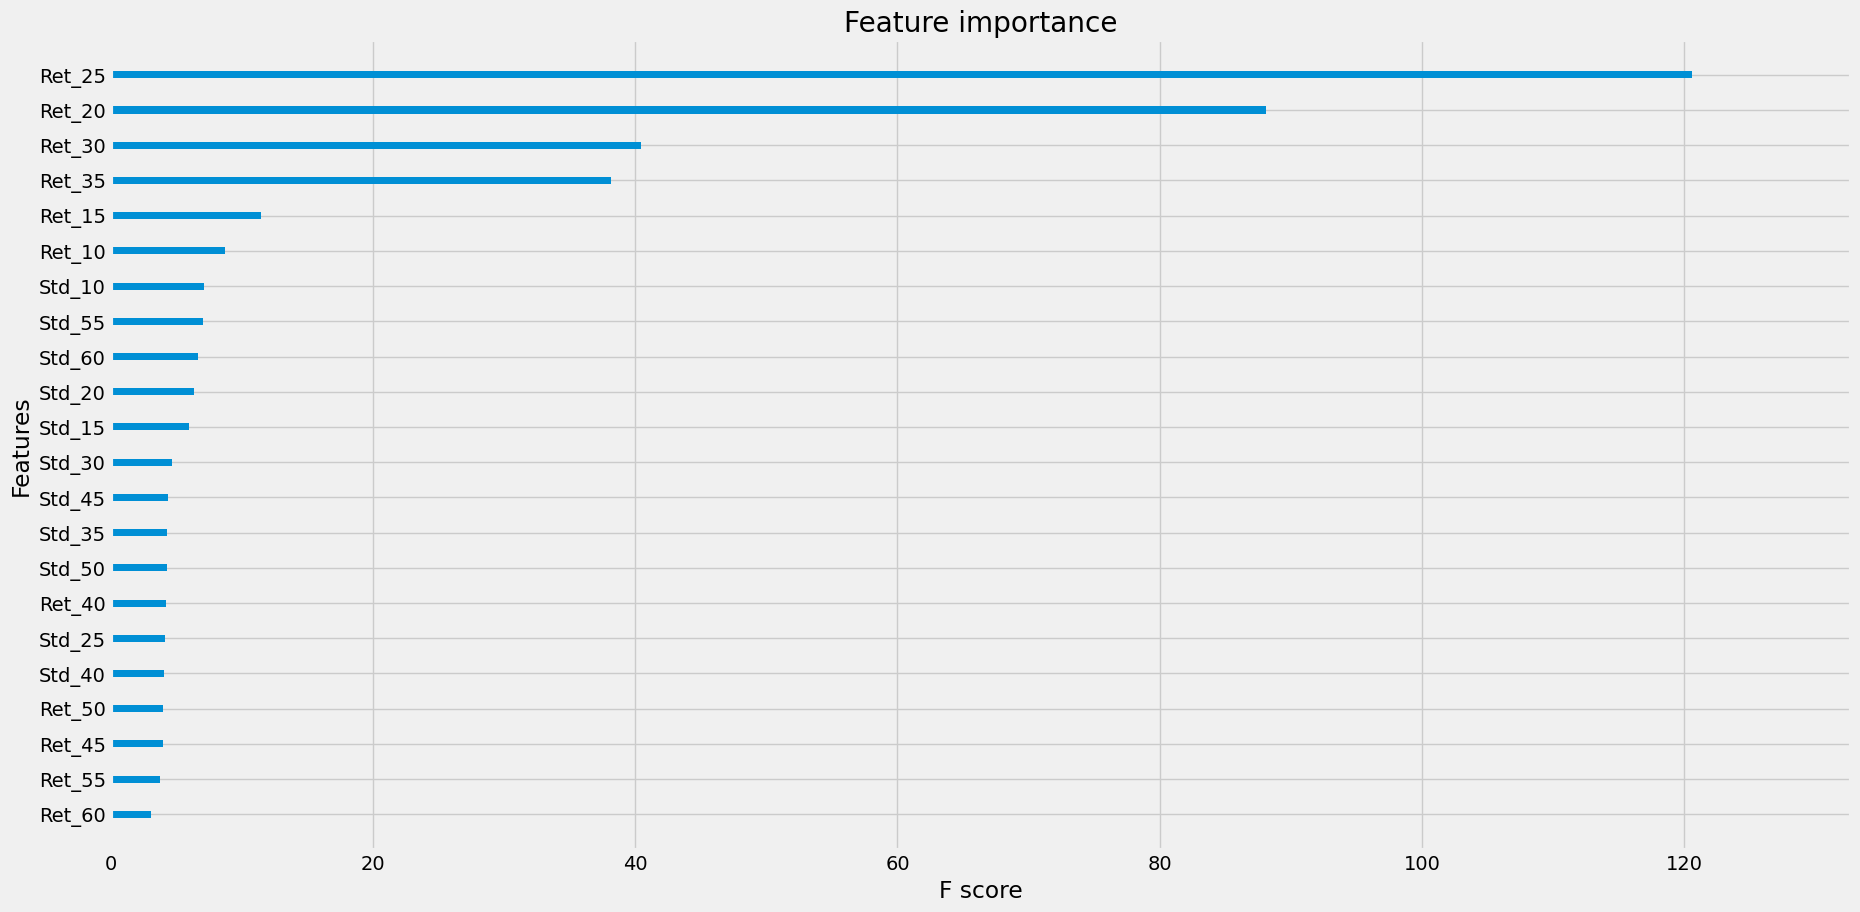

In [33]:
# feature importance_type = 'gain'
plot_importance(cls, importance_type='gain', show_values=False);

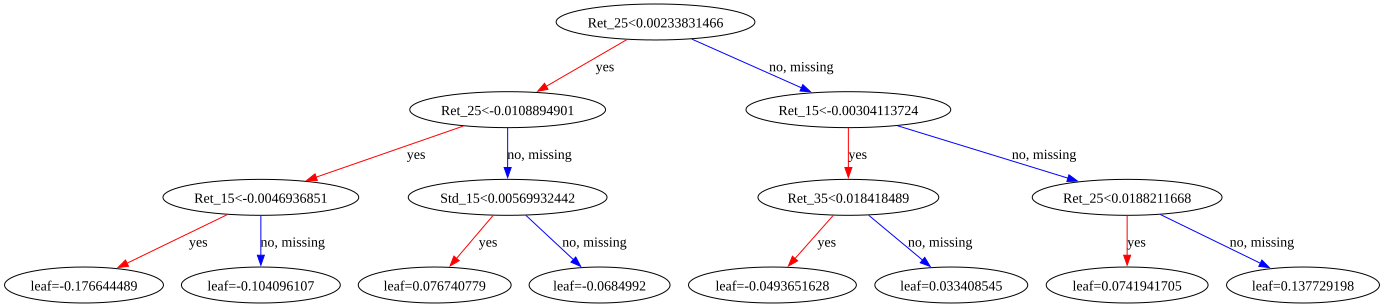

In [35]:
## Tree Visualization
# change tree number to see the corresponding plot
to_graphviz(cls, num_trees=2, rankdir='UT')

For a classification tree with two classes, the value of the leaf node represent the raw score. It can be converted to a probability score by using the logistic (sigmoid) function.

## Predict Refitted Model

In [36]:
# Predicting the test dataset
y_pred = cls.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [37]:
# Measure Accuracy
acc_train = accuracy_score(y_train, cls.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)
acc_train, acc_test

(0.9260450160771704, 0.9258160237388724)

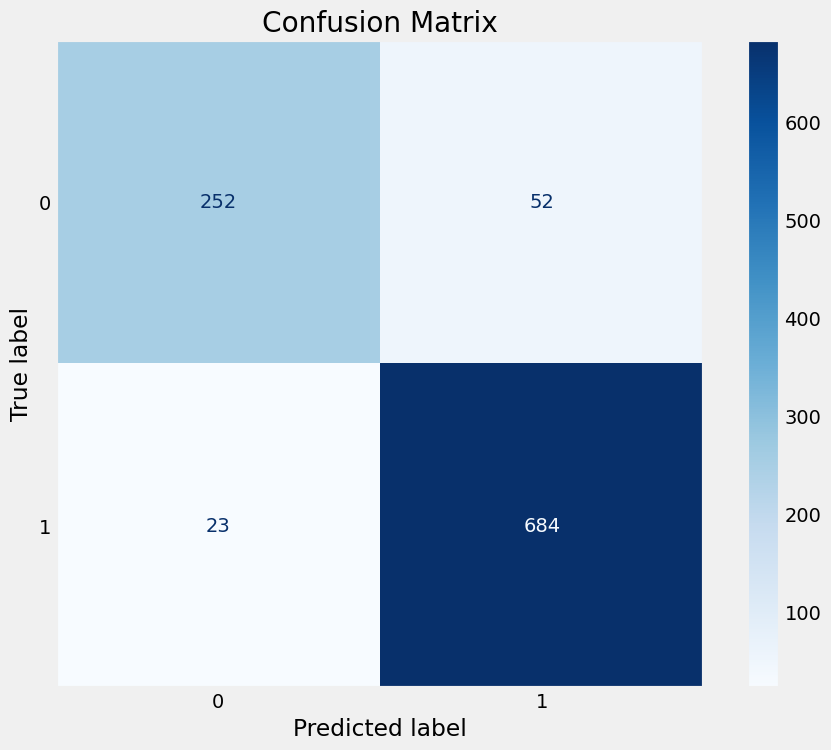

In [40]:
# 假设 cls, X_test, y_test 已定义
# 先计算混淆矩阵
y_pred = cls.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues', values_format='.4g')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

In [41]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       304
           1       0.93      0.97      0.95       707

    accuracy                           0.93      1011
   macro avg       0.92      0.90      0.91      1011
weighted avg       0.93      0.93      0.92      1011



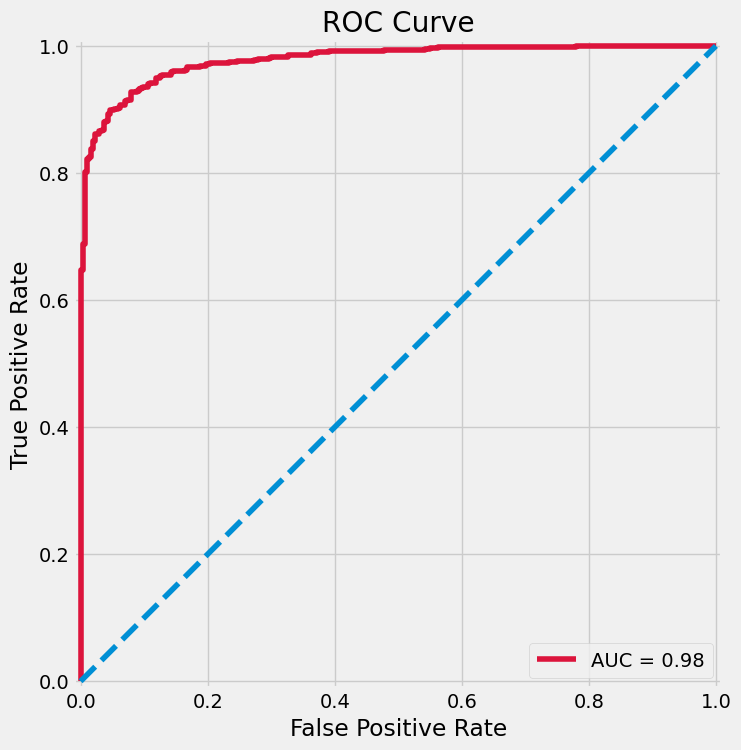

In [42]:
# 假设 cls, X_test, y_test 已定义
# 计算 ROC 曲线所需的数据
y_pred_proba = cls.predict_proba(X_test)[:, 1]  # 获取正类的概率
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
fig, ax = plt.subplots(figsize=(10, 8))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax, color='crimson')
ax.plot([0, 1], [0, 1], linestyle='--')  # 绘制对角线
ax.set_title('ROC Curve')
plt.show()

In [43]:
# Cross validation score
score=cross_val_score(cls,X_train,y_train,cv=tscv)

In [44]:
print(f'Mean CV Score : {score.mean():0.4}')

Mean CV Score : 0.9016


# Trading Strategy

Let's now define a trading strategy. We assign a value of +1 for the buy signal and -1 otherwise from the predicted price y_pred for the outsample horizon. We then compare the result of this strategy with the buy and hold and visualize the performance of the Tree Algorithm.

In [45]:
# Create a new dataframe to subsume outsample data
df1 = df[-len(y_test):]

# Predict the signal and store in predicted signal column
df1['Signal'] = y_pred

# Calculate the strategy returns
df1['Strategy'] = df1['Returns'] * df1['Signal'].shift(1).fillna(0)

# Localize index for pyfolio
df1.index = df1.index.tz_localize('utc')

# Check the output
df1[['Adj Close', 'Returns', 'Signal', 'Strategy']].tail(10)

,Adj Close,Returns,Signal,Strategy
Date,,,,
2020-04-16 00:00:00+00:00,279.100006,0.004813,1,0.004813
2020-04-17 00:00:00+00:00,286.640015,0.026657,1,0.026657
2020-04-20 00:00:00+00:00,281.589996,-0.017775,1,-0.017775
2020-04-21 00:00:00+00:00,273.040009,-0.030834,1,-0.030834
2020-04-22 00:00:00+00:00,279.100006,0.021952,1,0.021952
2020-04-23 00:00:00+00:00,279.079987,-0.000072,1,-0.000072
2020-04-24 00:00:00+00:00,282.970001,0.013842,1,0.013842
2020-04-27 00:00:00+00:00,287.049988,0.014315,1,0.014315
2020-04-28 00:00:00+00:00,285.730011,-0.004609,1,-0.004609


We'll now apply exponential function to arrive at the performance of the strategy and compare it with the simple Buy and Hold.

## Strategy Performance

In [46]:
# Import pyfolio
import pyfolio as pf
import pandas as pd

# 为 pd.Series 添加 iteritems 方法，指向 items 方法
if not hasattr(pd.Series, 'iteritems'):
    pd.Series.iteritems = pd.Series.items

Start date,2016-04-25
End date,2020-04-29
Total months,48
,Backtest
Annual return,8.9%
Cumulative returns,40.6%
Annual volatility,9.2%
Sharpe ratio,0.97
Calmar ratio,0.69
Stability,0.90
Max drawdown,-12.8%


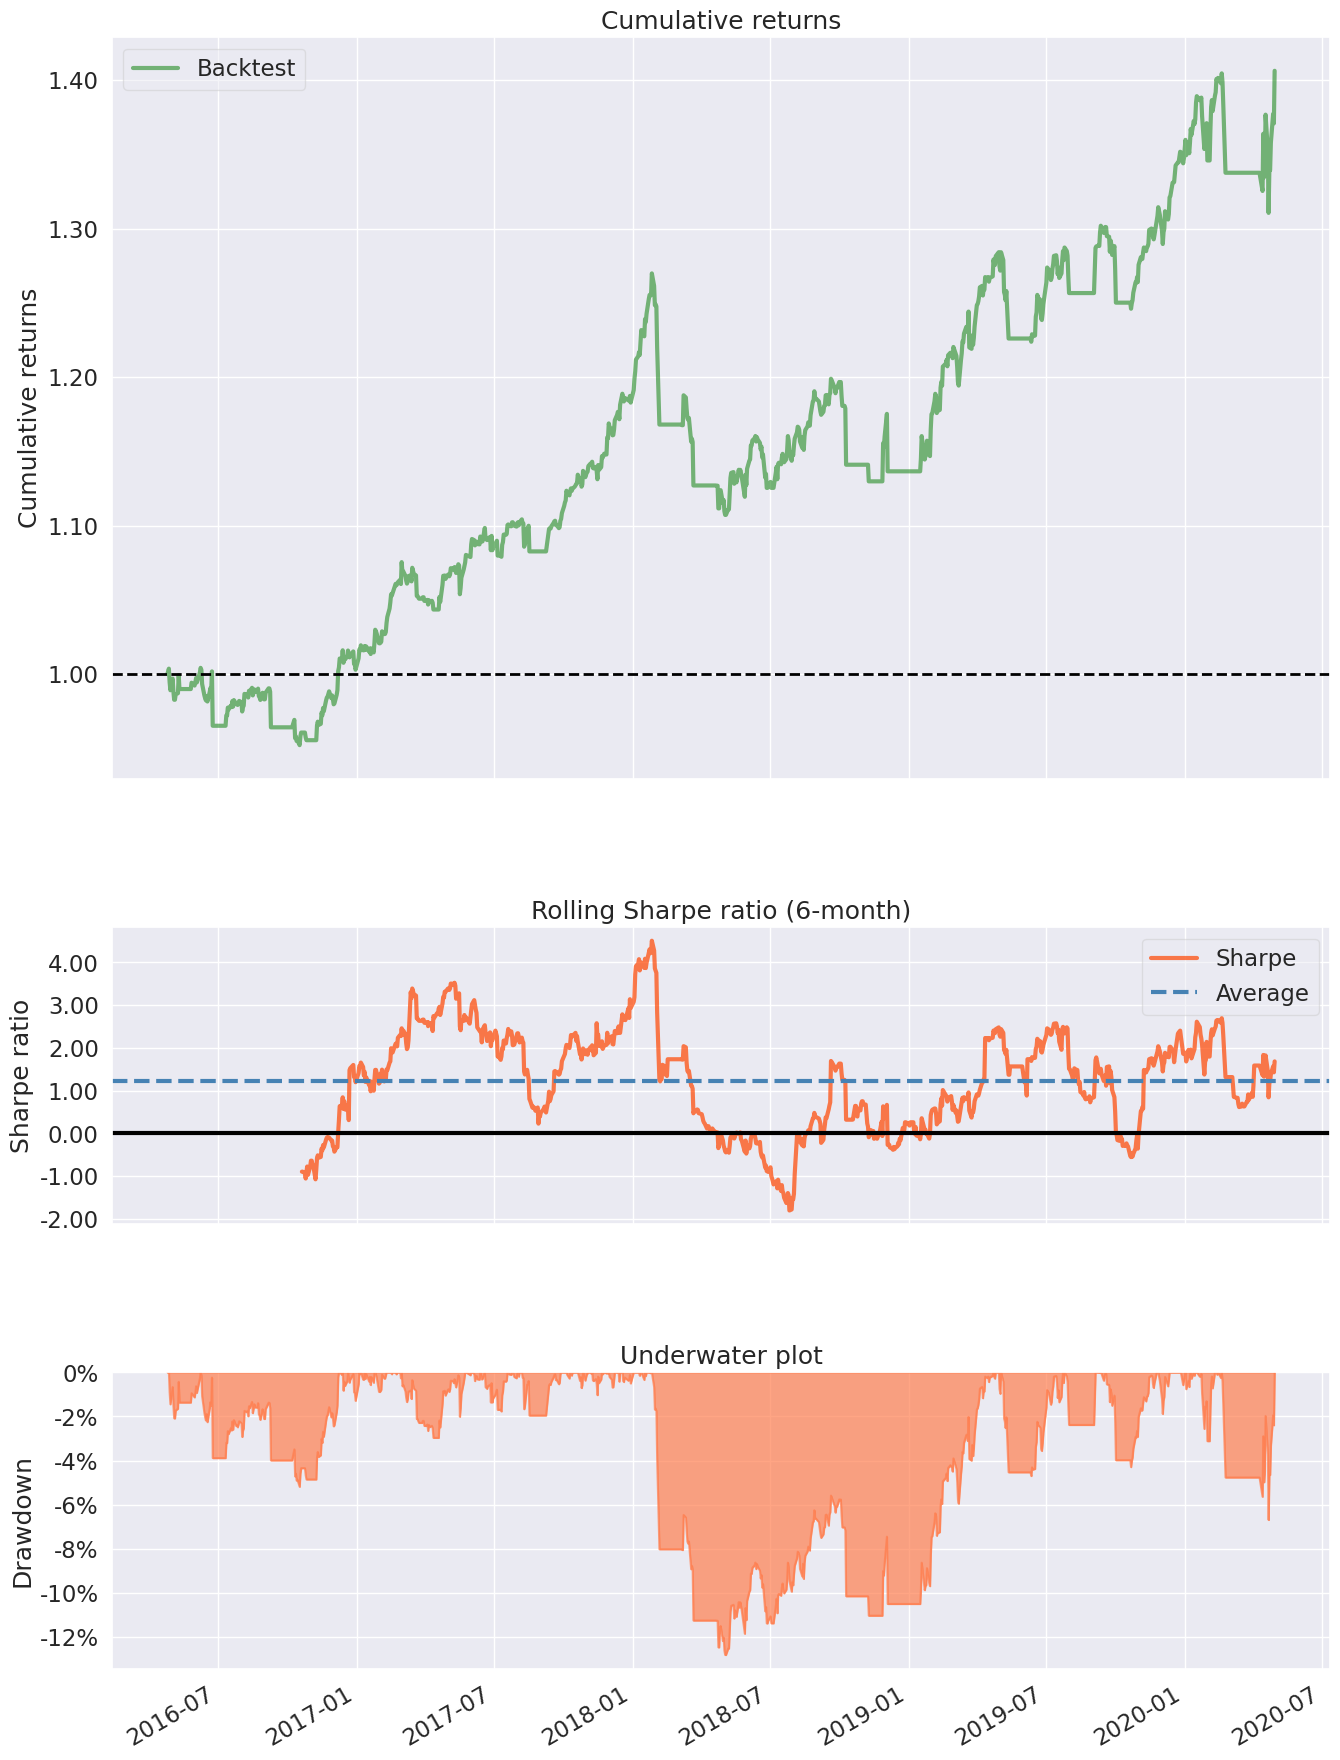

In [47]:
# Create Tear sheet using pyfolio for outsample - for X_test
pf.create_simple_tear_sheet(df1['Strategy'])

# References
Cross-validation  
TimeSeriesSplit  
RandomizedSearchCV  
Hyperparameters Tuning  
Metrics & Scoring  
Introduction to Boosted Trees  
XGBoost documentation  
XGBoost (clone) documentation  
Pyfolio-reloaded